In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("bengaluru_house_prices.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [19]:
print("Shape:", df.shape)
df.info()

print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (13320, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB

Missing values:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Duplicates: 529


In [20]:
df.describe(include="all")

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
count,13320,13320,13319,13304,7818,13320,13247.000000,12711.000000,13320.000000
unique,4,81,1305,31,2688,2117,NaN,NaN,NaN
top,Super built-up Area,Ready To Move,Whitefield,2 BHK,GrrvaGr,1200,NaN,NaN,NaN
freq,8790,10581,540,5199,80,843,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2.692610,1.584376,112.565627
std,NaN,NaN,NaN,NaN,NaN,NaN,1.341458,0.817263,148.971674
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,8.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,50.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,72.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,2.000000,120.000000


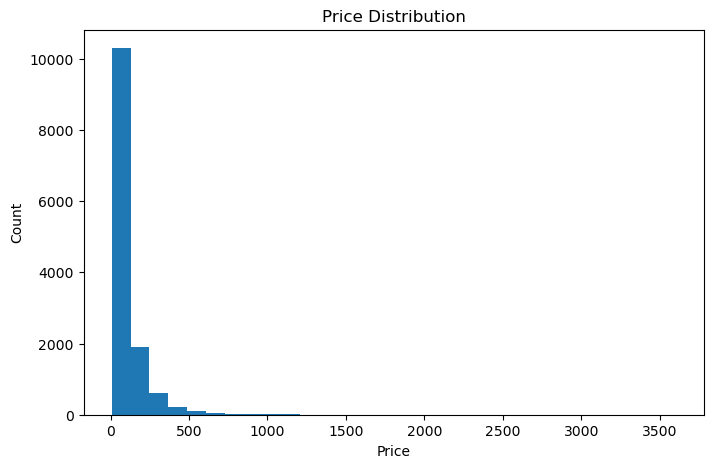

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

## Cleaning

In [22]:
df = df.drop_duplicates().copy()
df = df.drop(columns=["society"])
df = df.dropna(subset=["location", "size"])
df["bath"] = df["bath"].fillna(df["bath"].median())
df["balcony"] = df["balcony"].fillna(df["balcony"].median())

df["bhk"] = df["size"].str.extract(r"(\d+)").astype(int)
df = df.drop(columns=["size"])

def convert_sqft(value):
    try:
        value = str(value)
        if "-" in value:
            a,b = value.split("-")[:2]
            return (float(a)+float(b))/2
        return float(value)
    except:
        return np.nan

df["total_sqft"] = df["total_sqft"].apply(convert_sqft)
df = df.dropna(subset=["total_sqft"])
df = df.drop(columns=["availability"])

print("Shape after cleaning:", df.shape)
print("Missing values left:")
print(df.isnull().sum())

Shape after cleaning: (12728, 7)
Missing values left:
area_type     0
location      0
total_sqft    0
bath          0
balcony       0
price         0
bhk           0
dtype: int64


## Outlier Handling — IQR

We follow the lecturer's order: handle outliers **before** Train/Test Split. For this dataset, applying IQR to all one-hot columns would be wrong because rare locations would be treated as outliers. Therefore the IQR filter is applied only to real numeric variables. `price_per_sqft` is used **for cleaning only**, not as a model feature.

In [23]:
df["price_per_sqft"] = (df["price"] * 100000) / df["total_sqft"]

outlier_cols = ["price_per_sqft", "total_sqft", "bath", "bhk", "price"]
Q1 = df[outlier_cols].quantile(0.25)
Q3 = df[outlier_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[outlier_cols] < (Q1 - 1.5*IQR)) | (df[outlier_cols] > (Q3 + 1.5*IQR))).any(axis=1)
df_clean = df.loc[~outlier_mask].copy()

print("Before outlier removal:", df.shape)
print("After outlier removal:", df_clean.shape)
print("Removed:", df.shape[0]-df_clean.shape[0])

Before outlier removal: (12728, 8)
After outlier removal: (10239, 8)
Removed: 2489


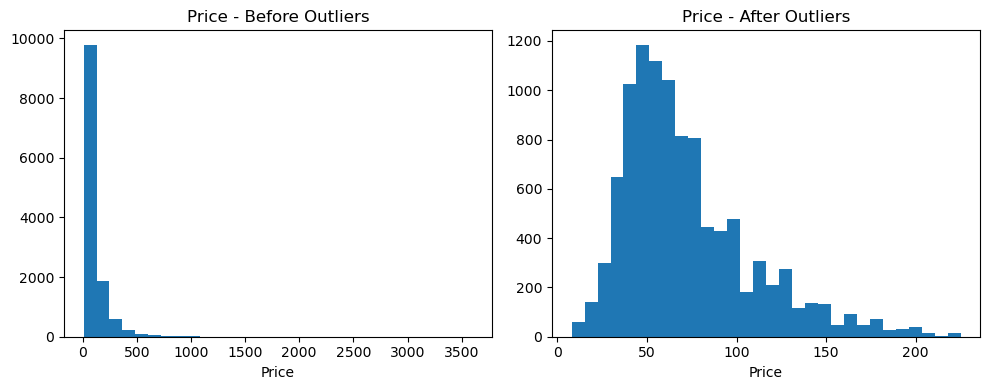

In [24]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df["price"], bins=30)
plt.title("Price - Before Outliers")
plt.xlabel("Price")
plt.subplot(1,2,2)
plt.hist(df_clean["price"], bins=30)
plt.title("Price - After Outliers")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

## Preprocessing

In [25]:
# price_per_sqft was for outlier detection only
df_clean = df_clean.drop(columns=["price_per_sqft"])

df_model = pd.get_dummies(df_clean, columns=["area_type", "location"], drop_first=True)
bool_columns = df_model.select_dtypes(include="bool").columns
df_model[bool_columns] = df_model[bool_columns].astype(int)

print("Model shape:", df_model.shape)
print("Missing values:", df_model.isnull().sum().sum())

Model shape: (10239, 1071)
Missing values: 0


In [26]:
X = df_model.drop(columns=["price"])
y = df_model["price"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8191, 1070)
X_test: (2048, 1070)
y_train: (8191,)
y_test: (2048,)


In [27]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.to_numpy().reshape(-1,1))
y_test_scaled = target_scaler.transform(y_test.to_numpy().reshape(-1,1))

print(X_train_scaled.shape, X_test_scaled.shape)
print(y_train_scaled.shape, y_test_scaled.shape)

(8191, 1070) (2048, 1070)
(8191, 1) (2048, 1)


## FCNN Regression Model

This is **Regression**, so the output is `Dense(1, activation="linear")`. We do not use accuracy as the main metric because accuracy is not meaningful for continuous house prices. We use MAE during training and R²/MAE after converting predictions back to the original price scale.

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="linear")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mae"]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       137,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,969 (578.00 KB)

 Trainable params: 147,969 (578.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6)

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0252 - mae: 0.1157 - val_loss: 0.0118 - val_mae: 0.0800 - learning_rate: 0.0010
Epoch 2/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0085 - mae: 0.0672 - val_loss: 0.0092 - val_mae: 0.0680 - learning_rate: 0.0010
Epoch 3/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0067 - mae: 0.0595 - val_loss: 0.0089 - val_mae: 0.0667 - learning_rate: 0.0010
Epoch 4/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0060 - mae: 0.0561 - val_loss: 0.0089 - val_mae: 0.0658 - learning_rate: 0.0010
Epoch 5/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0055 - mae: 0.0533 - val_loss: 0.0087 - val_mae: 0.0651 - learning_rate: 0.0010
Epoch 6/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0052 - mae: 0.0514 - val_loss: 0.0088 - val_mae: 0.0654 - learning_rate: 0.0010
Epoch 7/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0049 - mae: 0.0498 - val_loss: 0.0088 - val_mae: 0.0657 - learning_rate: 0.00

## Training Curves

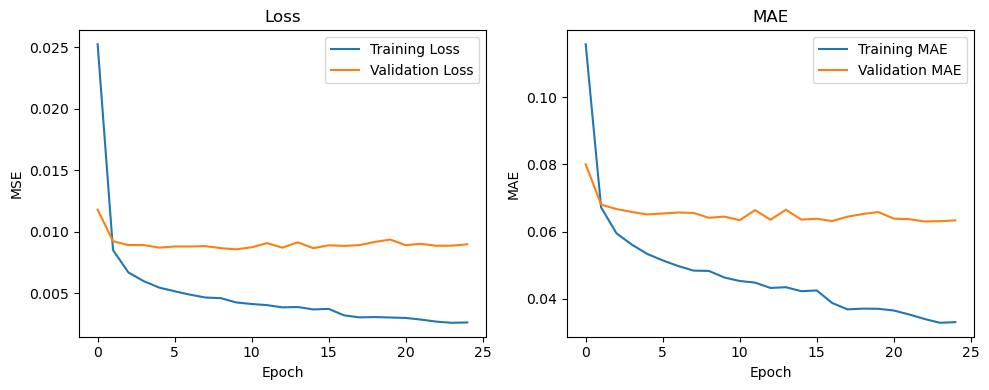

In [30]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Loss"); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.title("MAE"); plt.legend()
plt.tight_layout(); plt.show()

## Final Test Evaluation

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_scaled = model.predict(X_test_scaled, verbose=0)
y_pred = target_scaler.inverse_transform(y_pred_scaled).ravel()
y_test_original = y_test.to_numpy()

test_r2 = r2_score(y_test_original, y_pred)
test_mae = mean_absolute_error(y_test_original, y_pred)

print("Test R²:", test_r2)
print("Test MAE:", test_mae)

Test R²: 0.7342826282498727
Test MAE: 13.269134755264968


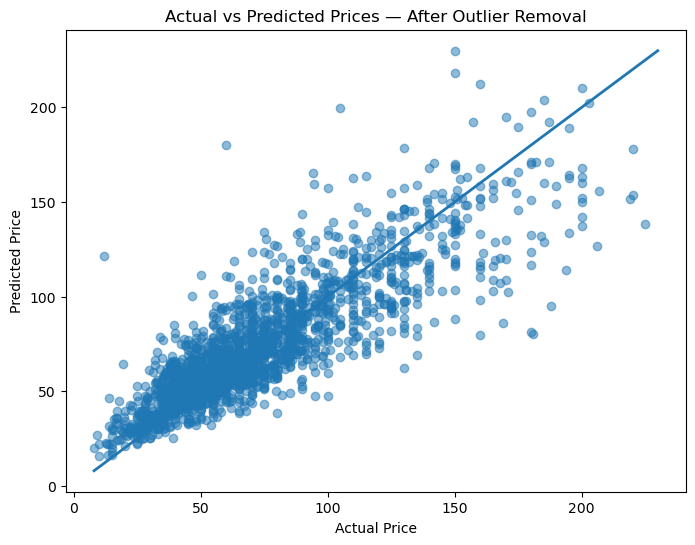

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
min_value = min(y_test_original.min(), y_pred.min())
max_value = max(y_test_original.max(), y_pred.max())
plt.plot([min_value,max_value],[min_value,max_value], linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices — After Outlier Removal")
plt.show()

### How to read the final result

The diagonal line represents perfect prediction. The closer the points are to that line, the better the model. **R² is the main final metric for this regression task.**

In [33]:
results = pd.DataFrame({"Actual Price": y_test_original, "Predicted Price": y_pred})
results.head(10)

,Actual Price,Predicted Price
0,75.00,74.289490
1,58.00,47.793087
2,67.00,77.740776
3,38.12,47.340370
4,61.26,44.266068
5,180.00,170.218185
6,35.00,40.942604
7,70.00,73.182617
8,102.00,107.998131
9,85.00,114.740875
